In [11]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# Pull a small slice of Point Harvest (CDIP station 71) via OPeNDAP
url = "https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/071p1_rt.nc"
ds = xr.open_dataset(url)
print(ds)

<xarray.Dataset> Size: 69MB
Dimensions:                     (sourceCount: 24803, waveTime: 24592,
                                 metaBoundsCount: 2, waveFrequency: 64,
                                 sstTime: 24592, gpsTime: 24592, dwrTime: 24592)
Coordinates:
  * waveTime                    (waveTime) datetime64[ns] 197kB 2024-11-08T20...
  * waveFrequency               (waveFrequency) float32 256B 0.025 0.03 ... 0.58
  * sstTime                     (sstTime) datetime64[ns] 197kB 2024-11-08T20:...
  * gpsTime                     (gpsTime) datetime64[ns] 197kB 2024-11-08T20:...
  * dwrTime                     (dwrTime) datetime64[ns] 197kB 2024-11-08T20:...
    metaDeployLatitude          float32 4B ...
    metaDeployLongitude         float32 4B ...
Dimensions without coordinates: sourceCount, metaBoundsCount
Data variables: (12/51)
    sourceFilename              (sourceCount) object 198kB ...
    waveTimeBounds              (waveTime, metaBoundsCount) datetime64[ns] 393kB ...
    

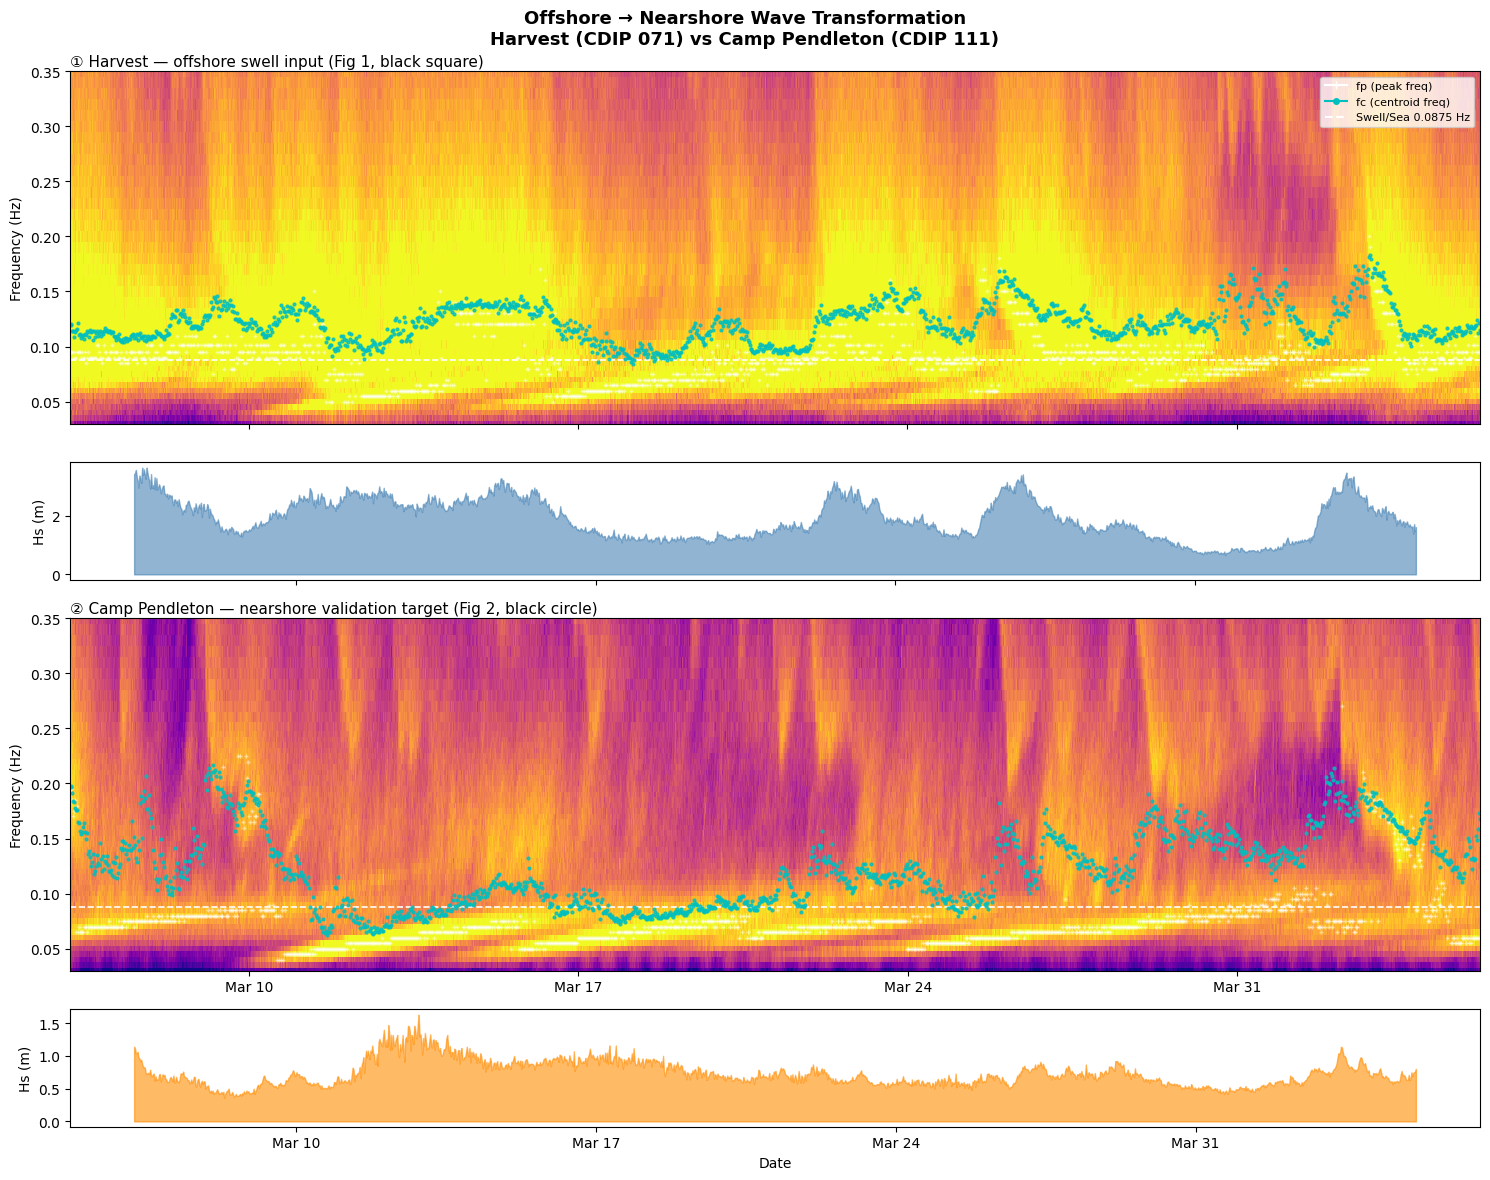

Done


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr

# --- Load both buoys ---
ds_harvest = xr.open_dataset(
    "http://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/071p1_rt.nc"
)
ds_camp = xr.open_dataset(
    "http://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/264p1_rt.nc"
)

def extract(ds, days=30):
    """Pull energy, freqs, times, Hs, fp, fc for last N days."""
    E     = ds['waveEnergyDensity'].values
    freqs = ds['waveFrequency'].values
    times = ds['waveTime'].values
    Hs    = ds['waveHs'].values
    Tp    = ds['waveTp'].values
    fp    = 1.0 / Tp

    cutoff = np.datetime64('now') - np.timedelta64(days, 'D')
    mask   = times >= cutoff
    E, times, Hs, fp = E[mask], times[mask], Hs[mask], fp[mask]

    fc = np.sum(freqs[np.newaxis, :] * E, axis=1) / np.sum(E, axis=1)
    return E, freqs, times, Hs, fp, fc

E_h, freqs_h, times_h, Hs_h, fp_h, fc_h = extract(ds_harvest)
E_c, freqs_c, times_c, Hs_c, fp_c, fc_c = extract(ds_camp)

# --- Shared color scale so panels are directly comparable ---
vmin, vmax = -4, 0

fig, axes = plt.subplots(4, 1, figsize=(15, 12),
                          gridspec_kw={'height_ratios': [3, 1, 3, 1]})
fig.suptitle('Offshore → Nearshore Wave Transformation\nHarvest (CDIP 071) vs Camp Pendleton (CDIP 111)',
             fontsize=13, fontweight='bold')

def plot_spectrogram(ax, E, freqs, times, fp, fc, title):
    log_E = np.log10(E.T + 1e-6)
    pcm = ax.pcolormesh(times, freqs, log_E,
                         cmap='plasma', shading='auto',
                         vmin=vmin, vmax=vmax)
    ax.axhline(0.0875, color='white', lw=1.2, ls='--')
    ax.plot(times, fp, 'w+', markersize=3, alpha=0.5, label='fp')
    ax.plot(times, fc, 'co', markersize=2, alpha=0.8, label='fc')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_ylim(0.03, 0.35)
    ax.set_title(title, fontsize=11, loc='left', pad=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.tick_params(labelbottom=False)
    return pcm

def plot_hs(ax, times, Hs, color):
    ax.fill_between(times, Hs, alpha=0.6, color=color)
    ax.set_ylabel('Hs (m)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))

# Harvest
pcm = plot_spectrogram(axes[0], E_h, freqs_h, times_h, fp_h, fc_h,
                        '① Harvest — offshore swell input (Fig 1, black square)')
plot_hs(axes[1], times_h, Hs_h, 'steelblue')
axes[1].tick_params(labelbottom=False)

# Camp Pendleton
plot_spectrogram(axes[2], E_c, freqs_c, times_c, fp_c, fc_c,
                  '② Camp Pendleton — nearshore validation target (Fig 2, black circle)')
axes[2].tick_params(labelbottom=True)
plot_hs(axes[3], times_c, Hs_c, 'darkorange')
axes[3].set_xlabel('Date')

# Legend on first spectrogram
axes[0].legend(loc='upper right', fontsize=8,
               handles=[
                   plt.Line2D([0],[0], marker='+', color='w', label='fp (peak freq)', markersize=6),
                   plt.Line2D([0],[0], marker='o', color='c', label='fc (centroid freq)', markersize=4),
                   plt.Line2D([0],[0], color='w', ls='--', label='Swell/Sea 0.0875 Hz')
               ])

plt.tight_layout()
plt.savefig('harvest_vs_camp_pendleton.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done")

In [20]:
# Run this cell first to see what directional variables we have
import xarray as xr

ds = xr.open_dataset(
    "http://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/071p1_rt.nc"
)

# Print just the wave variables
for var in ds.data_vars:
    if 'wave' in var.lower():
        print(f"{var}: {ds[var].dims} — {ds[var].attrs.get('long_name', '')}")

waveTimeBounds: ('waveTime', 'metaBoundsCount') — time cell bounds
waveFlagPrimary: ('waveTime',) — primary wave QC flag
waveFlagSecondary: ('waveTime',) — secondary wave QC flag
waveHs: ('waveTime',) — significant wave height
waveTp: ('waveTime',) — peak wave period
waveTa: ('waveTime',) — average wave period
waveDp: ('waveTime',) — peak wave direction
wavePeakPSD: ('waveTime',) — peak wave power spectral density
waveTz: ('waveTime',) — spectral zero-upcross wave period
waveSourceIndex: ('waveTime',) — source file index
waveFrequencyBounds: ('waveFrequency', 'metaBoundsCount') — frequency cell bounds
waveFrequencyFlagPrimary: ('waveFrequency',) — primary waveFrequency QC flag
waveFrequencyFlagSecondary: ('waveFrequency',) — secondary waveFrequency QC flag
waveBandwidth: ('waveFrequency',) — bandwidth
waveEnergyDensity: ('waveTime', 'waveFrequency') — band energy density
waveMeanDirection: ('waveTime', 'waveFrequency') — band mean direction
waveA1Value: ('waveTime', 'waveFrequency') — 

In [21]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset(
    "http://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/071p1_rt.nc"
)

times  = ds['waveTime'].values
Hs     = ds['waveHs'].values
Dp     = ds['waveDp'].values    # peak direction — bulk summary of where swell is from

# Trim to last 30 days
cutoff = np.datetime64('now') - np.timedelta64(30, 'D')
mask   = times >= cutoff
times_30  = times[mask]
Hs_30     = Hs[mask]
Dp_30     = Dp[mask]

# Find the top 5 highest energy moments — these are our candidate swell events
top5_idx = np.argsort(Hs_30)[-5:][::-1]
print("Top 5 highest energy timesteps in last 30 days:")
for i in top5_idx:
    print(f"  {times_30[i]}  Hs={Hs_30[i]:.2f}m  Dp={Dp_30[i]:.0f}°")

Top 5 highest energy timesteps in last 30 days:
  2026-03-06T09:30:00.000000000  Hs=3.65m  Dp=306°
  2026-03-06T12:00:00.000000000  Hs=3.65m  Dp=310°
  2026-03-06T10:30:00.000000000  Hs=3.59m  Dp=306°
  2026-03-06T06:00:00.000000000  Hs=3.57m  Dp=300°
  2026-04-03T13:00:00.000000000  Hs=3.48m  Dp=309°


Using timestep: 2026-03-06T09:30:00.000000000
S2d max at dirs[316] = 316.0°  (should be ~306°)


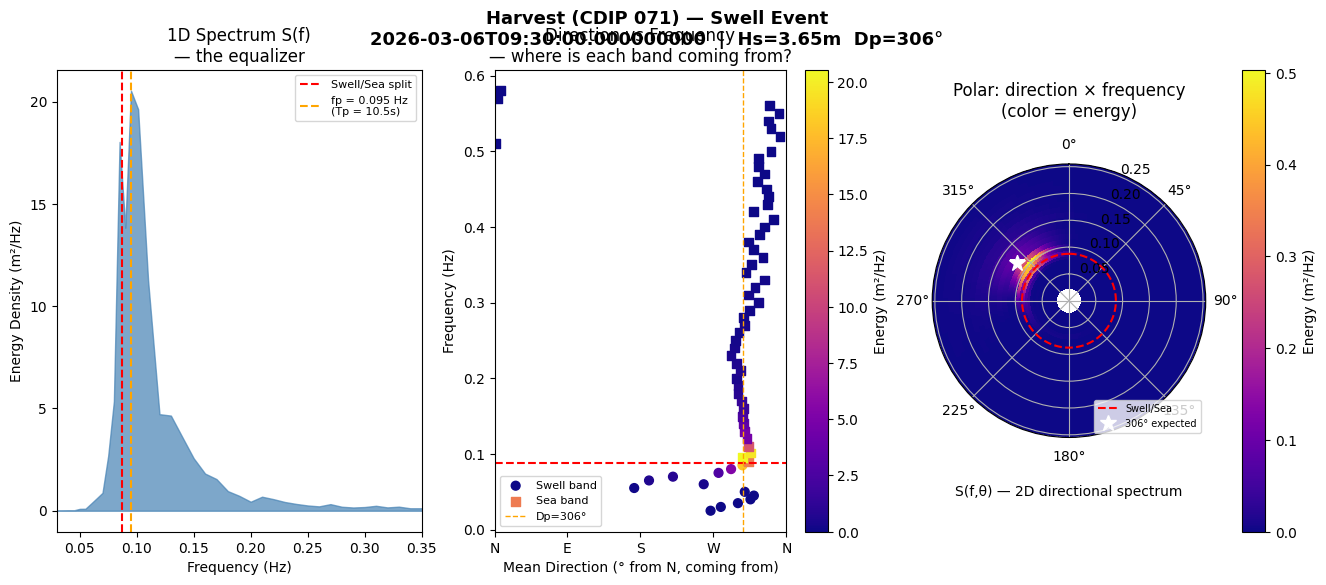

In [26]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm

ds = xr.open_dataset(
    "http://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/071p1_rt.nc"
)

times  = ds['waveTime'].values
freqs  = ds['waveFrequency'].values

# --- Find the exact index of our target timestep ---
target = np.datetime64('2026-03-06T09:30:00')
t_idx  = np.argmin(np.abs(times - target))
print(f"Using timestep: {times[t_idx]}")

# --- Pull the spectral data at that moment ---
E    = ds['waveEnergyDensity'].values[t_idx, :]      # energy at each frequency
D    = ds['waveMeanDirection'].values[t_idx, :]      # mean direction at each frequency
sprd = ds['waveSpread'].values[t_idx, :]             # directional spread at each freq
a1   = ds['waveA1Value'].values[t_idx, :]
b1   = ds['waveB1Value'].values[t_idx, :]

# --- Reconstruct a simple 2D spectrum S(f, theta) ---
# We use a wrapped Gaussian approximation:
# S(f,θ) ≈ E(f) * G(θ; D(f), spread(f))
# where G is a normalized Gaussian centered at mean direction D
# This is a simplification of MEM but captures the essential shape

n_dirs = 360
dirs   = np.linspace(0, 359, n_dirs)   # directions in degrees

def wrapped_gaussian(theta, mu, sigma):
    """Normalized wrapped Gaussian — handles 0/360 boundary."""
    theta = np.array(theta)
    diff  = theta[:, np.newaxis] - mu[np.newaxis, :]   # (n_dirs x n_freqs)
    # Wrap to [-180, 180]
    diff  = (diff + 180) % 360 - 180
    G     = np.exp(-0.5 * (diff / sigma[np.newaxis, :])**2)
    G     = G / G.sum(axis=0, keepdims=True)            # normalize each freq
    return G

# Build S(f, theta): shape (n_dirs, n_freqs)
G    = wrapped_gaussian(dirs, D, sprd)
S2d  = G * E[np.newaxis, :]    # broadcast energy across directions

# --- Figure: 3 panels ---
fig = plt.figure(figsize=(16, 6))
fig.suptitle(f'Harvest (CDIP 071) — Swell Event\n{times[t_idx]}  |  Hs=3.65m  Dp=306°',
             fontsize=13, fontweight='bold')

# --- Panel 1: 1D energy spectrum S(f) ---
ax1 = fig.add_subplot(131)
ax1.fill_between(freqs, E, alpha=0.7, color='steelblue')
ax1.axvline(0.0875, color='red', lw=1.5, ls='--', label='Swell/Sea split')

# Mark peak
peak_idx = np.argmax(E)
ax1.axvline(freqs[peak_idx], color='orange', lw=1.5, ls='--',
            label=f'fp = {freqs[peak_idx]:.3f} Hz\n(Tp = {1/freqs[peak_idx]:.1f}s)')

ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Energy Density (m²/Hz)')
ax1.set_title('1D Spectrum S(f)\n— the equalizer')
ax1.legend(fontsize=8)
ax1.set_xlim(0.03, 0.35)

# --- Panel 2: Mean direction vs frequency ---
ax2 = fig.add_subplot(132)

# Color points by swell vs sea band
swell = freqs <= 0.0875
sea   = freqs > 0.0875
sc1 = ax2.scatter(D[swell], freqs[swell], c=E[swell],
                   cmap='plasma', s=40, label='Swell band',
                   norm=plt.Normalize(0, E.max()))
sc2 = ax2.scatter(D[sea], freqs[sea], c=E[sea],
                   cmap='plasma', s=40, marker='s', label='Sea band',
                   norm=plt.Normalize(0, E.max()))
ax2.axhline(0.0875, color='red', lw=1.5, ls='--')
ax2.axvline(306, color='orange', lw=1, ls='--', label='Dp=306°')
ax2.set_xlabel('Mean Direction (° from N, coming from)')
ax2.set_ylabel('Frequency (Hz)')
ax2.set_title('Direction vs Frequency\n— where is each band coming from?')
ax2.set_xlim(0, 360)
ax2.set_xticks([0, 90, 180, 270, 360])
ax2.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
ax2.legend(fontsize=8)
plt.colorbar(sc1, ax=ax2, label='Energy (m²/Hz)')

# --- Panel 3: Polar plot S(f, theta) ---
# --- Rebuild S2d with explicit direction check ---
n_dirs = 360
dirs   = np.arange(0, 360, 1.0)   # 0 to 359, integer steps, compass degrees

def wrapped_gaussian(theta_grid, mu, sigma):
    """
    theta_grid: (n_dirs,) compass degrees
    mu: (n_freqs,) mean directions in compass degrees  
    sigma: (n_freqs,) spread in degrees
    returns: (n_dirs, n_freqs) normalized Gaussian
    """
    diff = theta_grid[:, np.newaxis] - mu[np.newaxis, :]  # (n_dirs x n_freqs)
    diff = (diff + 180) % 360 - 180                        # wrap to [-180, 180]
    G    = np.exp(-0.5 * (diff / sigma[np.newaxis, :])**2)
    G    = G / G.sum(axis=0, keepdims=True)
    return G

G   = wrapped_gaussian(dirs, D, sprd)
S2d = G * E[np.newaxis, :]

# Verify max direction in S2d
max_dir_idx, max_freq_idx = np.unravel_index(np.argmax(S2d), S2d.shape)
print(f"S2d max at dirs[{max_dir_idx}] = {dirs[max_dir_idx]:.1f}°  (should be ~306°)")

# --- Panel 3: Polar plot ---
ax3 = fig.add_subplot(133, projection='polar')

freq_mask = freqs <= 0.25

# Key: set theta convention BEFORE pcolormesh
ax3.set_theta_zero_location('N')
ax3.set_theta_direction(-1)

# Now pass compass degrees directly as radians
dirs_rad = np.deg2rad(dirs)

pcm = ax3.pcolormesh(dirs_rad, freqs[freq_mask],
                      S2d[:, freq_mask].T,
                      cmap='plasma', shading='auto')

ax3.set_title('Polar: direction × frequency\n(color = energy)', pad=15)
ax3.set_xlabel('S(f,θ) — 2D directional spectrum', labelpad=15)

# Swell/sea ring
theta_ring = np.linspace(0, 2*np.pi, 100)
ax3.plot(theta_ring, np.full(100, 0.0875), 'r--', lw=1.5, label='Swell/Sea')

# Mark 306° explicitly so we can verify
ax3.plot(np.deg2rad(306), 0.12, 'w*', markersize=12, label='306° expected')
ax3.legend(fontsize=7, loc='lower right')

plt.colorbar(pcm, ax=ax3, label='Energy (m²/Hz)', pad=0.1)

In [25]:
# Diagnostic — let's verify the direction data directly
print(f"Dp from bulk parameter: 306°")
print(f"\nAt the peak energy frequency ({freqs[peak_idx]:.3f} Hz):")
print(f"  waveMeanDirection = {D[peak_idx]:.1f}°")
print(f"  waveA1 = {a1[peak_idx]:.3f}")
print(f"  waveB1 = {b1[peak_idx]:.3f}")
print(f"  Direction from a1/b1: {np.rad2deg(np.arctan2(b1[peak_idx], a1[peak_idx])) % 360:.1f}°")

# Check what direction the max energy in S2d is at
max_dir_idx, max_freq_idx = np.unravel_index(np.argmax(S2d), S2d.shape)
print(f"\nIn S2d, max energy is at:")
print(f"  dirs[{max_dir_idx}] = {dirs[max_dir_idx]:.1f}°")
print(f"  freqs[{max_freq_idx}] = {freqs[max_freq_idx]:.3f} Hz")

Dp from bulk parameter: 306°

At the peak energy frequency (0.095 Hz):
  waveMeanDirection = 305.9°
  waveA1 = 0.554
  waveB1 = -0.765
  Direction from a1/b1: 305.9°

In S2d, max energy is at:
  dirs[316] = 316.0°
  freqs[15] = 0.101 Hz
